In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv("sales_data.csv")

print("First 5 records:")
print(df.head())
print("\nLast 5 records:")
print(df.tail())
print("\nShape (rows, columns) :", df.shape)
print("Column names          :", list(df.columns))
print("Total elements        :", df.size)

First 5 records:
   Product Region  Sales
0   Laptop  North  50000
1   Mobile  South  35000
2  Printer   East  25000
3   Laptop   West  45000
4   Mobile  North  40000

Last 5 records:
    Product Region  Sales
25   Mobile  South  37000
26  Printer   East  33000
27   Laptop   West  49000
28   Mobile  North  41000
29  Printer  South  34000

Shape (rows, columns) : (30, 3)
Column names          : ['Product', 'Region', 'Sales']
Total elements        : 90


In [2]:
# ---------------- Inspecting the structure of the dataset ----------------
print("Information about the dataset:")
df.info()

print("\nData types of each column:")
print(df.dtypes)

print("\nStatistical summary of the numeric columns:")
print(df.describe())

print("\nSummary of all the columns including the categorical ones:")
df.describe(include="all")

Information about the dataset:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Product  30 non-null     str  
 1   Region   30 non-null     str  
 2   Sales    30 non-null     int64
dtypes: int64(1), str(2)
memory usage: 852.0 bytes

Data types of each column:
Product      str
Region       str
Sales      int64
dtype: object

Statistical summary of the numeric columns:
              Sales
count     30.000000
mean   40033.333333
std     9575.411518
min    25000.000000
25%    32250.000000
50%    39500.000000
75%    47750.000000
max    58000.000000

Summary of all the columns including the categorical ones:


,Product,Region,Sales
count,30,30,30.000000
unique,3,4,NaN
top,Laptop,North,NaN
freq,10,8,NaN
mean,NaN,NaN,40033.333333
std,NaN,NaN,9575.411518
min,NaN,NaN,25000.000000
25%,NaN,NaN,32250.000000
50%,NaN,NaN,39500.000000
75%,NaN,NaN,47750.000000


In [3]:
# ---------------- Checking the quality of the data ----------------
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows :", df.duplicated().sum())

print("\nNumber of unique values in each column:")
print(df.nunique())

print("\nUnique products :", list(df["Product"].unique()))
print("Unique regions  :", list(df["Region"].unique()))

Missing values in each column:
Product    0
Region     0
Sales      0
dtype: int64

Duplicate rows : 0

Number of unique values in each column:
Product     3
Region      4
Sales      30
dtype: int64

Unique products : ['Laptop', 'Mobile', 'Printer']
Unique regions  : ['North', 'South', 'East', 'West']


In [4]:
# ---------------- Filtering using boolean conditions ----------------

# (a) single condition
high = df[df["Sales"] > 45000]
print("(a) Records with Sales greater than 45000 :", len(high))
print(high.head())

# (b) two conditions combined with AND
laptop_north = df[(df["Product"] == "Laptop") & (df["Region"] == "North")]
print("\n(b) Laptop sales in the North region:")
print(laptop_north)

# (c) two conditions combined with OR
either = df[(df["Sales"] > 55000) | (df["Sales"] < 26000)]
print("\n(c) Very high or very low sales:")
print(either)

(a) Records with Sales greater than 45000 : 9
   Product Region  Sales
0   Laptop  North  50000
6   Laptop   East  55000
9   Laptop  South  48000
12  Laptop  North  52000
15  Laptop   West  47000

(b) Laptop sales in the North region:
   Product Region  Sales
0   Laptop  North  50000
12  Laptop  North  52000
24  Laptop  North  56000

(c) Very high or very low sales:
    Product Region  Sales
2   Printer   East  25000
18   Laptop   East  58000
24   Laptop  North  56000


In [5]:
# ---------------- Filtering using isin(), between() and query() ----------------

# (a) isin() -> records belonging to a list of categories
subset = df[df["Region"].isin(["North", "South"])]
print("(a) Records from North and South :", len(subset))
print(subset.head())

# (b) between() -> records within a range of values
mid = df[df["Sales"].between(30000, 45000)]
print("\n(b) Records with Sales between 30000 and 45000 :", len(mid))

# (c) query() -> filtering with an expression
q = df.query("Product == 'Mobile' and Sales > 40000")
print("\n(c) Mobile records with Sales above 40000:")
print(q)

(a) Records from North and South : 16
   Product Region  Sales
0   Laptop  North  50000
1   Mobile  South  35000
4   Mobile  North  40000
5  Printer  South  30000
8  Printer  North  28000

(b) Records with Sales between 30000 and 45000 : 16

(c) Mobile records with Sales above 40000:
   Product Region  Sales
10  Mobile   East  42000
16  Mobile  North  43000
22  Mobile   East  44000
28  Mobile  North  41000


In [6]:
# ---------------- Selecting data using loc[] and iloc[] ----------------

print("(a) loc[] - rows 0 to 4, columns Product and Sales:")
print(df.loc[0:4, ["Product", "Sales"]])

print("\n(b) iloc[] - first 5 rows and first 2 columns:")
print(df.iloc[0:5, 0:2])

print("\n(c) iloc[] - a single value at row 3, column 2 :", df.iloc[3, 2])

# ---------------- Sorting the data ----------------
print("\n(d) Top 5 records sorted by Sales in descending order:")
print(df.sort_values("Sales", ascending=False).head())

(a) loc[] - rows 0 to 4, columns Product and Sales:
   Product  Sales
0   Laptop  50000
1   Mobile  35000
2  Printer  25000
3   Laptop  45000
4   Mobile  40000

(b) iloc[] - first 5 rows and first 2 columns:
   Product Region
0   Laptop  North
1   Mobile  South
2  Printer   East
3   Laptop   West
4   Mobile  North

(c) iloc[] - a single value at row 3, column 2 : 45000

(d) Top 5 records sorted by Sales in descending order:
   Product Region  Sales
18  Laptop   East  58000
24  Laptop  North  56000
6   Laptop   East  55000
12  Laptop  North  52000
21  Laptop  South  51000


In [7]:
# ---------------- Descriptive statistical analysis ----------------
s = df["Sales"]

print("Mean               :", round(s.mean(), 2))
print("Median             :", s.median())
print("Mode               :", s.mode().tolist())
print("Standard deviation :", round(s.std(), 2))
print("Variance           :", round(s.var(), 2))
print("Minimum            :", s.min())
print("Maximum            :", s.max())
print("Range              :", s.max() - s.min())
print("Sum                :", s.sum())
print("Count              :", s.count())

print("\nQuartiles:")
print("Q1 (25%) :", s.quantile(0.25))
print("Q2 (50%) :", s.quantile(0.50))
print("Q3 (75%) :", s.quantile(0.75))
print("IQR      :", s.quantile(0.75) - s.quantile(0.25))

Mean               : 40033.33
Median             : 39500.0
Mode               : [25000, 26000, 27000, 28000, 29000, 30000, 31000, 32000, 33000, 34000, 35000, 36000, 37000, 38000, 39000, 40000, 41000, 42000, 43000, 44000, 45000, 47000, 48000, 49000, 50000, 51000, 52000, 55000, 56000, 58000]
Standard deviation : 9575.41
Variance           : 91688505.75
Minimum            : 25000
Maximum            : 58000
Range              : 33000
Sum                : 1201000
Count              : 30

Quartiles:
Q1 (25%) : 32250.0
Q2 (50%) : 39500.0
Q3 (75%) : 47750.0
IQR      : 15500.0


In [8]:
# ---------------- Grouping and aggregation ----------------
print("Statistics of Sales grouped by Product:")
print(df.groupby("Product")["Sales"].agg(["count", "sum", "mean", "min", "max"]).round(2))

print("\nStatistics of Sales grouped by Region:")
print(df.groupby("Region")["Sales"].agg(["count", "sum", "mean"]).round(2))

print("\nTotal sales for every Product-Region combination:")
df.groupby(["Product", "Region"])["Sales"].sum().unstack()

Statistics of Sales grouped by Product:
         count     sum     mean    min    max
Product                                      
Laptop      10  511000  51100.0  45000  58000
Mobile      10  395000  39500.0  35000  44000
Printer     10  295000  29500.0  25000  34000

Statistics of Sales grouped by Region:
        count     sum      mean
Region                         
East        7  286000  40857.14
North       8  341000  42625.00
South       8  303000  37875.00
West        7  271000  38714.29

Total sales for every Product-Region combination:


Region,East,North,South,West
Product,,,,
Laptop,113000,158000,99000,141000
Mobile,86000,124000,108000,77000
Printer,87000,59000,96000,53000


In [9]:
# ---------------- Correlation analysis ----------------
# The Product and Region columns are categorical, so they are converted
# into numeric codes before the correlation is computed.
num = df.copy()
num["Product_Code"] = num["Product"].astype("category").cat.codes
num["Region_Code"] = num["Region"].astype("category").cat.codes

print("Encoded dataset:")
print(num.head())

corr = num[["Product_Code", "Region_Code", "Sales"]].corr()
print("\nCorrelation matrix:")
print(corr.round(4))

print("\nCorrelation between Product and Sales :",
      round(corr.loc["Product_Code", "Sales"], 4))
print("Correlation between Region and Sales  :",
      round(corr.loc["Region_Code", "Sales"], 4))

Encoded dataset:
   Product Region  Sales  Product_Code  Region_Code
0   Laptop  North  50000             0            1
1   Mobile  South  35000             1            2
2  Printer   East  25000             2            0
3   Laptop   West  45000             0            3
4   Mobile  North  40000             1            1

Correlation matrix:
              Product_Code  Region_Code   Sales
Product_Code        1.0000      -0.0751 -0.9367
Region_Code        -0.0751       1.0000 -0.1351
Sales              -0.9367      -0.1351  1.0000

Correlation between Product and Sales : -0.9367
Correlation between Region and Sales  : -0.1351


In [10]:
# ---------------- Correlation between the products ----------------
# The data is reshaped so that every product becomes a column and every
# region becomes a row. The correlation is then computed between the
# products across the regions.
matrix = df.pivot_table(index="Region", columns="Product",
                        values="Sales", aggfunc="sum")
print("Product versus Region matrix:")
print(matrix)

prod_corr = matrix.corr()
print("\nCorrelation between the products:")
print(prod_corr.round(4))

Product versus Region matrix:
Product  Laptop  Mobile  Printer
Region                          
East     113000   86000    87000
North    158000  124000    59000
South     99000  108000    96000
West     141000   77000    53000

Correlation between the products:
Product  Laptop  Mobile  Printer
Product                         
Laptop   1.0000  0.2335  -0.9275
Mobile   0.2335  1.0000   0.0865
Printer -0.9275  0.0865   1.0000


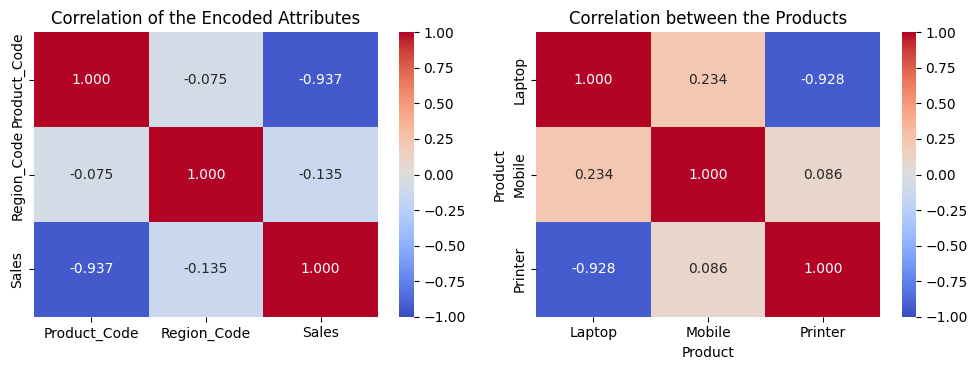

INTERPRETATION
A value close to +1 indicates a strong positive relationship,
a value close to -1 indicates a strong negative relationship and
a value close to 0 indicates that there is almost no relationship.


In [11]:
# ---------------- Visualising the correlation using a heatmap ----------------
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))

sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Correlation of the Encoded Attributes")

sns.heatmap(prod_corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title("Correlation between the Products")

plt.tight_layout()
plt.show()

print("INTERPRETATION")
print("A value close to +1 indicates a strong positive relationship,")
print("a value close to -1 indicates a strong negative relationship and")
print("a value close to 0 indicates that there is almost no relationship.")